# **Poverty Level Prediction in Indonesia using Socioeconomic Indicators**
**Author:** Harizky Pratama | Data Analyst

## **Project Overview**

**Dataset:** Badan Pusat Statistik (BPS) - Faktor Sosial Ekonomi

Dataset ini memuat indikator krusial terkait pembangunan masyarakat (seperti metrik pendidikan, pengeluaran, dan fasilitas kesehatan) yang merepresentasikan profil demografis pada tingkat Kabupaten/Kota di seluruh Indonesia.

**Methodology:** Extreme Gradient Boosting (XGBoost Regressor)

Mengingat kompleksitas dan sifat non-linear dari data sosial ekonomi, analisis ini mengimplementasikan algoritma *ensemble learning* berbasis *decision tree boosting* (XGBoost) untuk melakukan tugas regresi berkelanjutan pada target persentase penduduk miskin.

**Business Objectives:**
*   **Predictive Modeling:** Mengembangkan model prediktif yang *robust* untuk mengestimasi tingkat kemiskinan daerah secara akurat.
*   **Feature Importance:** Mengidentifikasi determinan sosial-ekonomi utama (seperti Indeks Pembangunan Manusia, rata-rata lama sekolah, dan PDRB) yang paling signifikan memengaruhi ketimpangan kesejahteraan.
*   **Actionable Insights:** Mengekstraksi temuan analitis berbasis data kuantitatif (tervalidasi oleh metrik evaluasi seperti RMSE dan R²) guna mendukung perumusan kebijakan pengentasan kemiskinan yang lebih presisi dan terukur.

# **Install & Import Library**

In [ ]:
# Install & Import Library
!pip install xgboost shap imbalanced-learn

# Data processing & analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Data preprocessing & model evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    explained_variance_score, median_absolute_error, max_error
)

In [ ]:
# Tampilan dataframe yang lebih rapi
pd.set_option('display.max_columns', None) #Menampilkan semua kolom tanpa dipotong
pd.set_option('display.width', None) #Mengatur lebar tampilan tabel
pd.set_option('display.float_format', '{:,.2f}'.format) #Menampilkan angka dengan 2 desimal dan pemisah ribuan


# **Dataset Overview & Data Dictionary**


Jumlah Dataset: 514 baris × 12 kolom

Jenis Dataset: Data tabular (CSV) yang berisi indikator sosial ekonomi di tingkat kabupaten/kota di Indonesia.

Deskripsi Singkat:
Dataset ini berisi informasi dari Badan Pusat Statistik (BPS) mengenai kondisi sosial dan ekonomi masyarakat di seluruh kabupaten/kota di Indonesia.
Setiap baris merepresentasikan satu wilayah (kabupaten/kota), dan setiap kolom menunjukkan indikator pembangunan manusia seperti kemiskinan, pendidikan, kesehatan, serta ekonomi.

Kolom-kolom utama dalam dataset:

- Provinsi → Nama provinsi tempat kabupaten/kota berada

- Kab/Kota → Nama kabupaten atau kota

- Persentase Penduduk Miskin (P0) → Persentase penduduk yang tergolong miskin (variabel target analisis)

- Rata-rata Lama Sekolah Penduduk 15+ (Tahun) → Indikator tingkat pendidikan

- Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun) → Indikator kesejahteraan ekonomi

- Indeks Pembangunan Manusia (IPM) → Ukuran komposit dari pendidikan, kesehatan, dan ekonomi

- Umur Harapan Hidup (Tahun) → Rata-rata usia harapan hidup masyarakat

- Persentase rumah tangga dengan akses sanitasi layak → Indikator fasilitas dasar

- Persentase rumah tangga dengan akses air minum layak → Indikator ketersediaan air bersih

- Tingkat Pengangguran Terbuka (TPT) → Persentase tenaga kerja yang tidak bekerja

- Tingkat Partisipasi Angkatan Kerja (TPAK) → Persentase penduduk usia kerja yang aktif secara ekonomi

- PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah) → Nilai Produk Domestik Regional Bruto daerah sebagai indikator ekonomi makro


In [ ]:
# 1. Load Dataset dari Google Drive
import pandas as pd

df = pd.read_csv('https://drive.google.com/uc?id=1M-xnXKAbv7CAQ_CCCEpbkJ0RVXcC9doS')

# 2. Tampilkan info dasar
print("Jumlah baris dan kolom:", df.shape)
print("\nInformasi Dataset:")
print(df.info())

# 3. Statistik deskriptif
print("\nStatistik Deskriptif:")
print(df.describe())

# 4. Lihat 5 baris pertama
print("\n5 Baris Pertama dalam Data:")
df.head()




Jumlah baris dan kolom: (514, 12)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 12 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Provinsi                                                              514 non-null    object 
 1   Kab/Kota                                                              514 non-null    object 
 2   Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)       514 non-null    float64
 3   Rata-rata Lama Sekolah Penduduk 15+ (Tahun)                           514 non-null    float64
 4   Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)          514 non-null    int64  
 5   Indeks Pembangunan Manusia                                            514 non-null    float64
 6   Umur Harapan Hidup (Tahun)                  

,Provinsi,Kab/Kota,Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen),Rata-rata Lama Sekolah Penduduk 15+ (Tahun),Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun),Indeks Pembangunan Manusia,Umur Harapan Hidup (Tahun),Persentase rumah tangga yang memiliki akses terhadap sanitasi layak,Persentase rumah tangga yang memiliki akses terhadap air minum layak,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah)
0,ACEH,Simeulue,18.98,9.48,7148,66.41,65.28,71.56,87.45,5.71,71.15,1648096
1,ACEH,Aceh Singkil,20.36,8.68,8776,69.22,67.43,69.56,78.58,8.36,62.85,1780419
2,ACEH,Aceh Selatan,13.18,8.88,8180,67.44,64.40,62.55,79.65,6.46,60.85,4345784
3,ACEH,Aceh Tenggara,13.41,9.67,8030,69.44,68.22,62.71,86.71,6.43,69.62,3487157
4,ACEH,Aceh Timur,14.45,8.21,8577,67.83,68.74,66.75,83.16,7.13,59.48,8433526


# **Exploration Data Analysis**


Tujuan EDA:

Melakukan eksplorasi terhadap data sosial ekonomi untuk memahami pola, distribusi, dan hubungan antar variabel, terutama untuk mengidentifikasi faktor-faktor yang berpengaruh terhadap tingkat kemiskinan (P0).
Hasil eksplorasi ini akan menjadi dasar bagi pembangunan model prediksi menggunakan algoritma XGBoost.

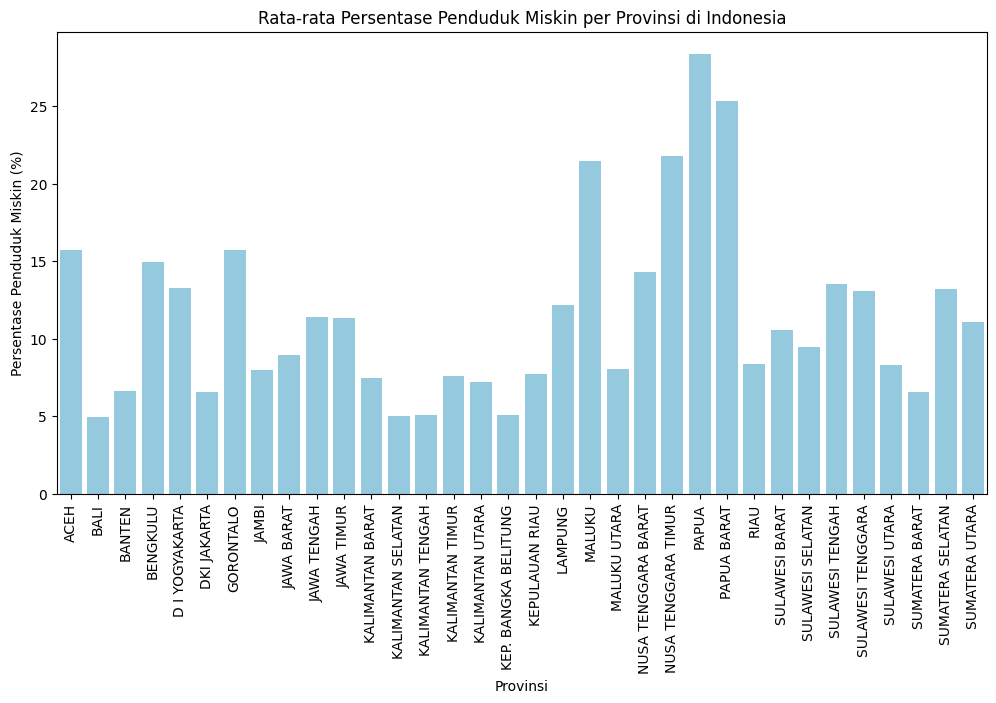

In [ ]:
# Visualisasi Rata-rata Kemiskinan per Provinsi
plt.figure(figsize=(12,6))
sns.barplot(
    data=df.groupby('Provinsi')['Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)'].mean().reset_index(),
    x='Provinsi',
    y='Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)',
    color='skyblue'
)
plt.xticks(rotation=90)
plt.title('Rata-rata Persentase Penduduk Miskin per Provinsi di Indonesia')
plt.xlabel('Provinsi')
plt.ylabel('Persentase Penduduk Miskin (%)')
plt.show()

Grafik batang di atas menampilkan rata-rata persentase penduduk miskin (P0) pada setiap provinsi di Indonesia. Visualisasi ini memberikan gambaran umum mengenai tingkat kemiskinan antarwilayah dan memperlihatkan adanya perbedaan yang cukup signifikan antara satu provinsi dengan provinsi lainnya.

Terlihat bahwa Provinsi Papua dan Papua Barat memiliki tingkat kemiskinan rata-rata tertinggi di Indonesia, masing-masing berada di atas 25%, jauh lebih tinggi dibandingkan provinsi lain. Hal ini menunjukkan adanya ketimpangan sosial-ekonomi yang masih cukup besar di wilayah Indonesia Timur, yang kemungkinan disebabkan oleh keterbatasan infrastruktur, akses pendidikan, serta kesempatan kerja yang belum merata.

Sementara itu, provinsi-provinsi di wilayah Jawa dan Bali, seperti DKI Jakarta, Bali, dan Jawa Tengah, cenderung memiliki tingkat kemiskinan rata-rata yang lebih rendah, umumnya berada di bawah 10%. Kondisi ini menggambarkan bahwa wilayah dengan pusat ekonomi yang lebih kuat dan infrastruktur yang lebih baik cenderung memiliki tingkat kemiskinan yang lebih kecil.

Selain itu, beberapa provinsi di wilayah Kalimantan dan Sumatera menunjukkan tingkat kemiskinan menengah, berada pada kisaran 10–15%, yang mencerminkan kondisi sosial-ekonomi yang relatif lebih stabil namun masih terdapat ruang untuk perbaikan terutama di sektor pemerataan pendapatan dan pembangunan daerah.

Secara keseluruhan, visualisasi ini menegaskan adanya disparitas kemiskinan antarwilayah di Indonesia, di mana wilayah timur masih tertinggal dibandingkan bagian barat. Temuan ini penting sebagai dasar analisis lanjutan untuk memahami faktor-faktor penyebab kemiskinan secara lebih mendalam dan bagaimana model prediksi selanjutnya dapat menangkap pola ketimpangan tersebut melalui variabel-variabel sosial-ekonomi yang relevan.

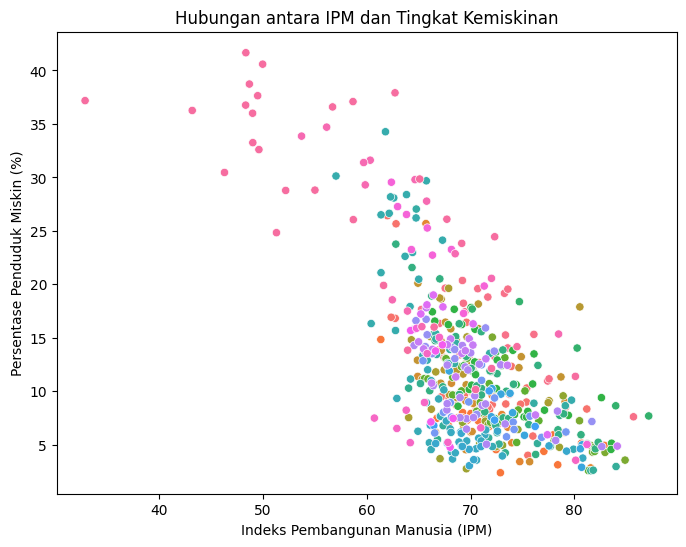

In [ ]:
# Hubungan antara IPM dan Tingkat Kemiskinan
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Indeks Pembangunan Manusia',
    y='Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)',
    hue='Provinsi',
    legend=False
)
plt.title('Hubungan antara IPM dan Tingkat Kemiskinan')
plt.xlabel('Indeks Pembangunan Manusia (IPM)')
plt.ylabel('Persentase Penduduk Miskin (%)')
plt.show()

Grafik scatter plot di atas menampilkan hubungan antara Indeks Pembangunan Manusia (IPM) dan persentase penduduk miskin (P0) di berbagai kabupaten/kota di Indonesia. Secara visual terlihat adanya pola korelasi negatif yang kuat, di mana wilayah dengan nilai IPM yang tinggi cenderung memiliki tingkat kemiskinan yang rendah. Sebaliknya, daerah dengan IPM rendah umumnya menunjukkan tingkat kemiskinan yang tinggi.

Pola ini menunjukkan bahwa peningkatan kualitas pembangunan manusia yang mencakup aspek pendidikan, kesehatan, dan pendapatan berkontribusi signifikan terhadap penurunan tingkat kemiskinan. Dengan kata lain, semakin baik kualitas hidup masyarakat di suatu wilayah, semakin kecil kemungkinan wilayah tersebut memiliki tingkat kemiskinan yang tinggi. Hubungan negatif ini juga memperlihatkan bahwa IPM dapat dijadikan indikator kunci kesejahteraan sosial ekonomi di tingkat daerah.

Hasil ini selaras dengan konsep Human Development Theory yang dikemukakan oleh UNDP, di mana pembangunan manusia menjadi fondasi utama dalam mengurangi kemiskinan struktural. Peningkatan akses terhadap pendidikan dan kesehatan menciptakan sumber daya manusia yang lebih produktif, sementara peningkatan pendapatan memperkuat daya beli masyarakat, sehingga secara keseluruhan menurunkan angka kemiskinan.

Selain memperkuat pemahaman teoritis, hasil ini juga mendukung relevansi IPM sebagai variabel prediktor penting dalam model machine learning yang digunakan, khususnya model XGBoost (Tuned). Karena model ini secara empiris juga menempatkan IPM sebagai salah satu fitur dengan importance tertinggi, maka hubungan negatif yang terlihat pada grafik ini memperkuat validitas model sekaligus memperlihatkan konsistensi antara hasil statistik dan interpretasi visual.


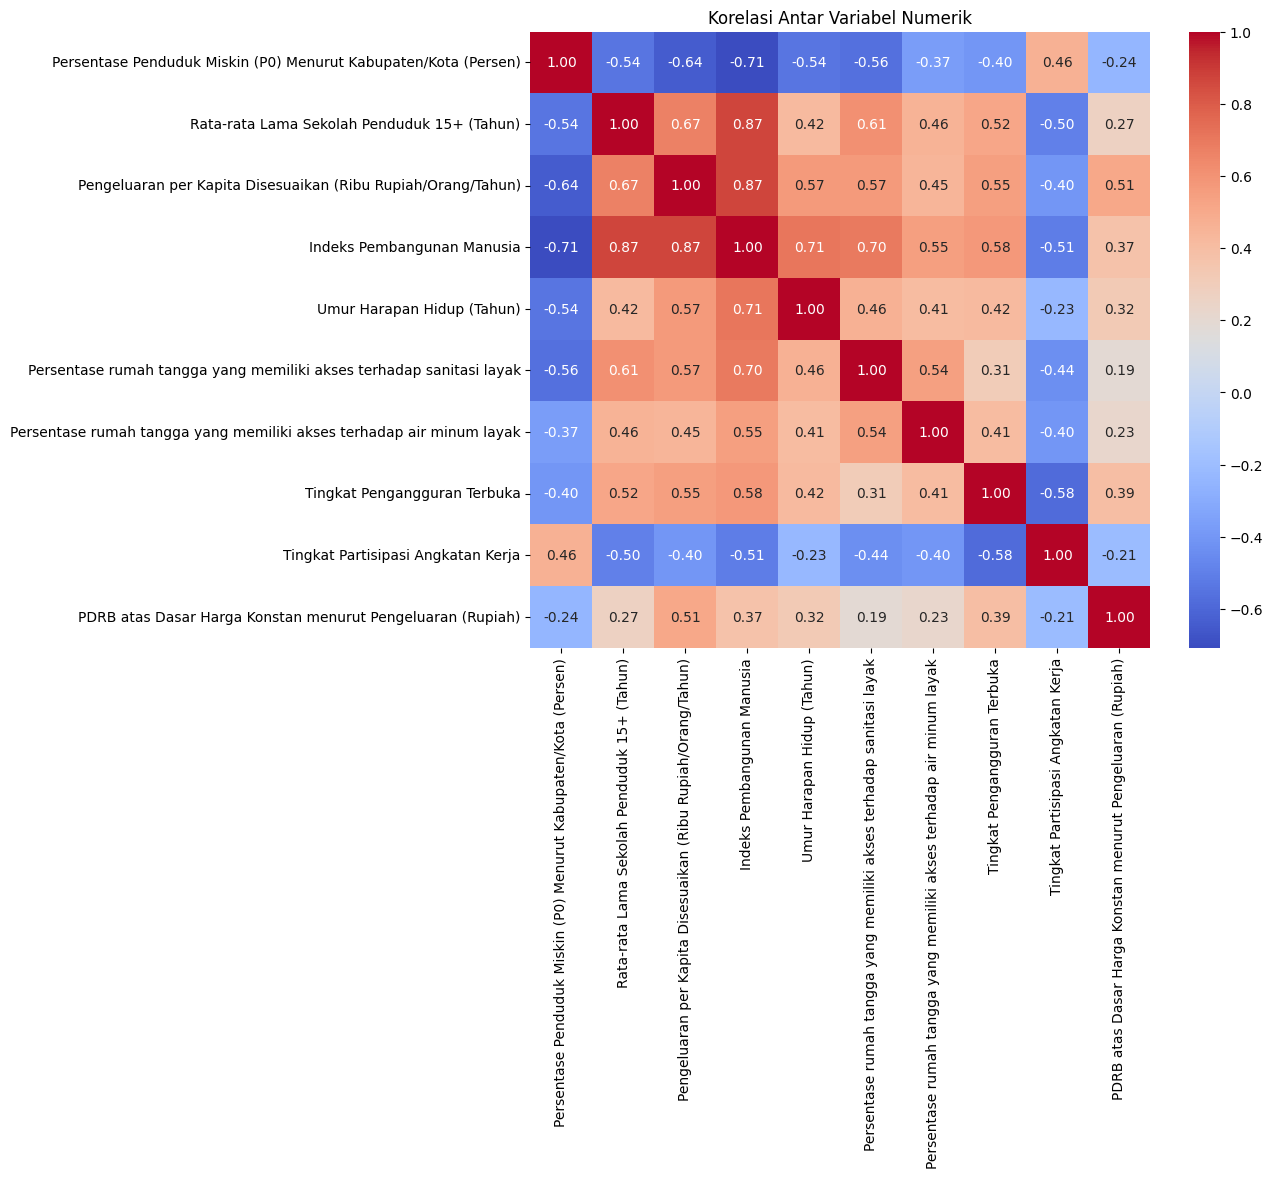

In [ ]:
# Korelasi antar variabel numerik
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi Antar Variabel Numerik')
plt.show()

Heatmap di atas memperlihatkan tingkat korelasi antar variabel numerik sosial ekonomi pada tingkat kabupaten/kota di Indonesia.
Warna merah menunjukkan hubungan positif (kedua variabel meningkat bersamaan), sedangkan warna biru menandakan korelasi negatif (jika satu naik, yang lain turun).

Berdasarkan hasil korelasi:

Persentase Penduduk Miskin (P0) berkorelasi negatif kuat dengan:

- Indeks Pembangunan Manusia (r = -0.71)

- Pengeluaran per Kapita (r = -0.64)

- Rata-rata Lama Sekolah (r = -0.54)

Hal ini menunjukkan bahwa semakin tinggi tingkat pendidikan dan kesejahteraan ekonomi, semakin rendah tingkat kemiskinan.

Indeks Pembangunan Manusia (IPM) memiliki korelasi positif kuat dengan:

- Rata-rata Lama Sekolah (r = 0.87)

- Pengeluaran per Kapita (r = 0.87)

- Umur Harapan Hidup (r = 0.71)

Korelasi positif ini konsisten dengan teori Human Development Index yang menjelaskan keterkaitan antara pendidikan, kesehatan, dan pendapatan.

- Tingkat Pengangguran Terbuka (TPT) justru menunjukkan hubungan positif lemah terhadap IPM (r = 0.52).

Hal ini bisa dijelaskan secara ekonomi bahwa daerah dengan IPM tinggi belum tentu memiliki penyerapan tenaga kerja yang optimal (misalnya kota besar dengan urban unemployment).

- PDRB (Produk Domestik Regional Bruto) memiliki korelasi positif sedang terhadap pengeluaran per kapita (r = 0.51), tetapi lemah terhadap kemiskinan (r = -0.24),
menandakan bahwa pertumbuhan ekonomi belum sepenuhnya inklusif di seluruh daerah.

Pola korelasi ini memperkuat temuan bahwa kemiskinan di Indonesia sangat dipengaruhi oleh dimensi pendidikan dan ekonomi rumah tangga, sedangkan dimensi ketenagakerjaan memiliki peran lebih kecil.
Oleh karena itu, variabel seperti IPM, Rata-rata Lama Sekolah, dan Pengeluaran per Kapita akan menjadi predictor penting dalam model XGBoost untuk memprediksi kemiskinan.

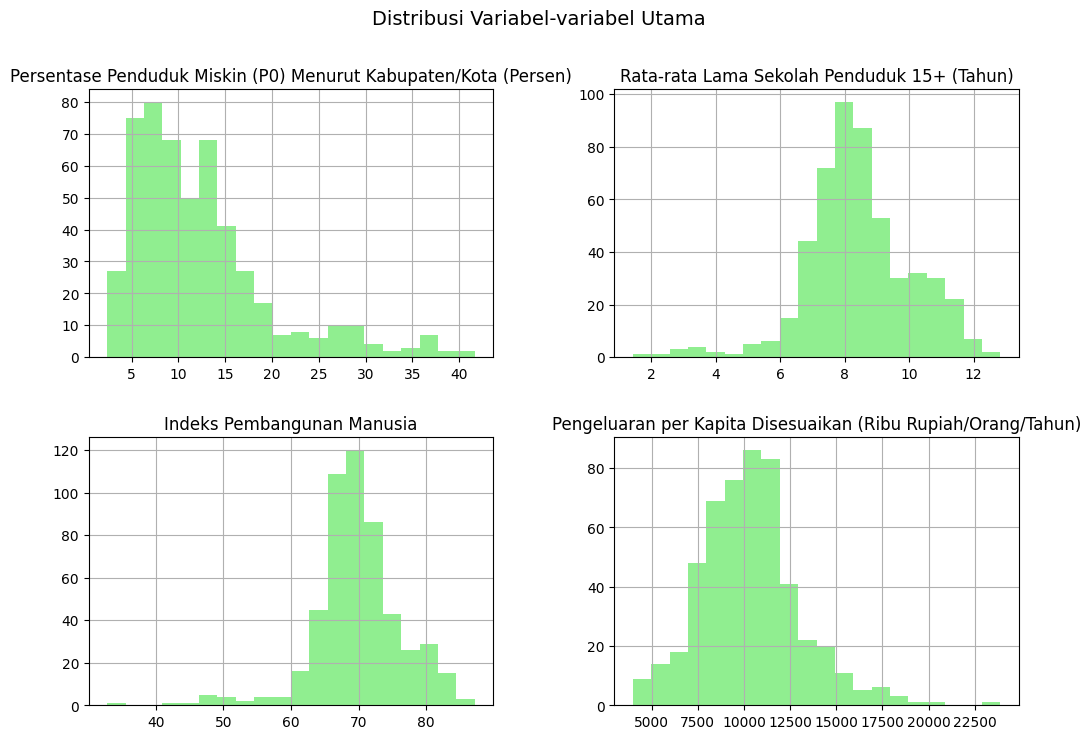

In [ ]:
# Distribusi variabel utama
num_cols = [
    'Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)',
    'Rata-rata Lama Sekolah Penduduk 15+ (Tahun)',
    'Indeks Pembangunan Manusia',
    'Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)'
]

df[num_cols].hist(figsize=(12,8), bins=20, color='lightgreen')
plt.suptitle('Distribusi Variabel-variabel Utama', fontsize=14)
plt.show()


Grafik di atas menampilkan distribusi empat variabel utama yang digunakan dalam analisis tingkat kemiskinan di Indonesia, yaitu:
(1) Persentase Penduduk Miskin (P0),
(2) Rata-rata Lama Sekolah Penduduk 15+ Tahun,
(3) Indeks Pembangunan Manusia (IPM), dan
(4) Pengeluaran per Kapita Disesuaikan (ribu rupiah/orang/tahun).

Dari histogram pertama terlihat bahwa persentase penduduk miskin (P0) memiliki distribusi yang condong ke kanan (right-skewed). Artinya, sebagian besar kabupaten/kota memiliki tingkat kemiskinan yang relatif rendah, namun terdapat beberapa wilayah dengan persentase kemiskinan yang jauh lebih tinggi. Hal ini menunjukkan adanya ketimpangan distribusi kesejahteraan antarwilayah, di mana sebagian kecil daerah masih tertinggal secara ekonomi.

Distribusi rata-rata lama sekolah penduduk berusia 15 tahun ke atas menunjukkan pola yang mendekati normal, dengan puncak di sekitar 7–9 tahun. Ini menunjukkan bahwa mayoritas penduduk telah menamatkan pendidikan dasar hingga menengah pertama, tetapi masih sedikit yang menempuh pendidikan menengah atas atau perguruan tinggi. Variabel ini penting karena lama pendidikan berhubungan erat dengan peluang kerja dan tingkat penghasilan individu.

Selanjutnya, distribusi Indeks Pembangunan Manusia (IPM) terlihat cukup terkonsentrasi pada rentang 60–75, menandakan bahwa sebagian besar kabupaten/kota berada pada kategori pembangunan manusia menengah. Meskipun demikian, masih terdapat sejumlah daerah dengan IPM rendah (<60), yang menggambarkan ketimpangan pembangunan antarwilayah, terutama antara Indonesia bagian barat dan timur.

Sementara itu, distribusi pengeluaran per kapita disesuaikan juga condong ke kanan, dengan sebagian besar daerah memiliki pengeluaran rata-rata antara 8.000–12.000 ribu rupiah per orang per tahun. Namun, terdapat beberapa daerah dengan pengeluaran sangat tinggi yang menjadi outlier, umumnya berasal dari wilayah perkotaan besar. Pola ini menggambarkan kesenjangan ekonomi yang nyata antara wilayah dengan tingkat urbanisasi tinggi dan wilayah perdesaan.

Secara keseluruhan, visualisasi ini memberikan gambaran awal yang sangat penting sebelum dilakukan pemodelan. Keempat variabel utama menunjukkan adanya variasi dan ketimpangan antarwilayah, yang menjadi dasar kuat bagi penggunaan metode machine learning seperti XGBoost untuk menangkap hubungan non-linear antar variabel sosial ekonomi terhadap tingkat kemiskinan di Indonesia.

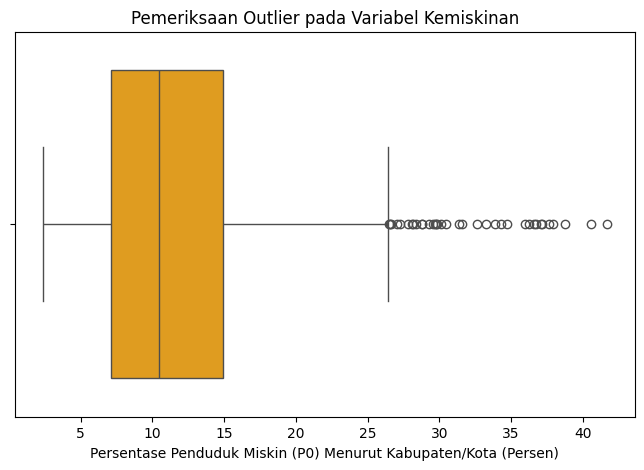

In [ ]:
# Pemeriksaan outlier pada P0
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)'], color='orange')
plt.title('Pemeriksaan Outlier pada Variabel Kemiskinan')
plt.show()


Grafik boxplot di atas menampilkan distribusi nilai Persentase Penduduk Miskin (P0) di seluruh kabupaten/kota di Indonesia. Visualisasi ini digunakan untuk mendeteksi keberadaan outlier atau nilai ekstrem yang dapat memengaruhi hasil analisis maupun performa model regresi.

Terlihat bahwa sebagian besar nilai P0 terkonsentrasi pada rentang 5% hingga 20%, dengan median berada di sekitar 10%–12%, menunjukkan bahwa separuh dari wilayah di Indonesia memiliki tingkat kemiskinan pada kisaran tersebut. Namun, terdapat sejumlah titik data yang berada jauh di atas whisker boxplot — titik-titik ini merupakan outlier positif, yang menandakan adanya daerah dengan tingkat kemiskinan jauh lebih tinggi dibandingkan sebagian besar wilayah lainnya.

Kemunculan outlier ini umumnya berasal dari wilayah-wilayah dengan kondisi sosial ekonomi tertinggal, terutama di kawasan Indonesia Timur seperti Papua dan Papua Barat, di mana tingkat kemiskinan dapat mencapai di atas 30%. Outlier tersebut bukan berarti kesalahan data, melainkan mencerminkan realitas ketimpangan ekonomi antarwilayah di Indonesia.

Secara analitis, keberadaan outlier ini penting untuk diperhatikan karena dapat memengaruhi hasil pemodelan, terutama jika menggunakan algoritma regresi linier yang sensitif terhadap nilai ekstrem. Namun, dalam konteks machine learning seperti XGBoost Regressor, model ini relatif robust terhadap outlier, sehingga informasi tersebut tetap dapat dipertahankan tanpa perlu dilakukan transformasi ekstrem seperti winsorizing atau trimming.

Dengan demikian, hasil pemeriksaan boxplot ini memperkuat pemahaman bahwa data kemiskinan di Indonesia memiliki sebaran yang tidak simetris dan mengandung nilai ekstrem yang signifikan, yang secara substantif menggambarkan kesenjangan pembangunan antarwilayah.

In [ ]:
# Rangkuman statistik indikator utama
cols = [
    'Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)',
    'Indeks Pembangunan Manusia',
    'Rata-rata Lama Sekolah Penduduk 15+ (Tahun)',
    'Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)'
]
df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen),514.00,12.27,7.46,2.38,7.15,10.46,14.89,41.66
Indeks Pembangunan Manusia,514.00,69.93,6.50,32.84,66.64,69.61,73.11,87.18
Rata-rata Lama Sekolah Penduduk 15+ (Tahun),514.00,8.44,1.63,1.42,7.51,8.30,9.34,12.83
Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun),514.00,"10,324.79","2,717.14","3,976.00","8,574.00","10,196.50","11,719.00","23,888.00"



Berdasarkan hasil analisis deskriptif terhadap data sosial ekonomi kabupaten/kota di Indonesia (n = 514), diperoleh beberapa informasi penting:

- Persentase Penduduk Miskin (P0) memiliki nilai rata-rata sebesar 12.27%, dengan simpangan baku 7.46%. Nilai minimum berada pada 2.38%, sedangkan maksimum mencapai 41.66%. Hal ini menunjukkan adanya variasi yang cukup besar antar wilayah, menandakan ketimpangan tingkat kemiskinan di Indonesia. Nilai maksimum 41.66% menunjukkan daerah-daerah dengan kemiskinan relatif tinggi, namun masih dalam batas realistis secara sosial ekonomi.

- Indeks Pembangunan Manusia (IPM) memiliki rata-rata 69.93, dengan sebaran yang cukup merata (std = 6.50). Nilai minimum sebesar 32.84 menandakan masih ada wilayah dengan kualitas pembangunan manusia yang sangat rendah, sedangkan nilai maksimum 87.18 mencerminkan daerah yang sudah maju (seperti kota besar).

- Rata-rata Lama Sekolah Penduduk 15+ memiliki nilai tengah sekitar 8.30 tahun, artinya secara umum masyarakat Indonesia menempuh pendidikan hingga tingkat SMP kelas 2. Nilai maksimum 12.83 tahun menunjukkan beberapa daerah dengan rata-rata pendidikan hampir setara SMA.

- Pengeluaran per Kapita Disesuaikan rata-ratanya 10.3 juta rupiah per tahun (atau sekitar 860 ribu per bulan), dengan nilai maksimum mencapai 23.9 juta per tahun. Variasi pengeluaran antar daerah cukup tinggi (std = 2.7 juta), yang menggambarkan kesenjangan ekonomi antar wilayah.

Dari hasil deskripsi di atas dapat disimpulkan bahwa terdapat ketimpangan antar kabupaten/kota baik dari sisi pendidikan, kesejahteraan ekonomi, maupun tingkat kemiskinan.
Secara umum, wilayah dengan IPM, lama sekolah, dan pengeluaran per kapita yang tinggi cenderung memiliki tingkat kemiskinan yang lebih rendah.

# **Preprocessing Data**


Tahap data preprocessing dilakukan untuk menyiapkan dataset agar siap digunakan dalam pemodelan menggunakan algoritma XGBoost. Tujuan utama tahap ini adalah untuk memastikan data bersih, bebas dari kesalahan, dan berada dalam format yang sesuai dengan kebutuhan analisis.

Tahapan preprocessing yang dilakukan meliputi:

- Langkah pertama adalah pembersihan struktur kolom dan karakter non-numerik, yaitu dengan menstandarkan nama kolom (menghapus spasi, mengganti huruf besar menjadi kecil) serta menghapus karakter seperti koma (,) dan tanda persen (%) yang dapat mengganggu proses konversi data numerik.

- Selanjutnya dilakukan transformasi tipe data, di mana seluruh kolom numerik diubah ke tipe float menggunakan fungsi pd.to_numeric(). Tahap ini memastikan semua variabel numerik dapat diolah secara statistik tanpa error tipe data.

- Kemudian dilakukan pemeriksaan dan penanganan nilai hilang (missing values). Berdasarkan hasil pemeriksaan, tidak ditemukan nilai kosong pada dataset. Namun, apabila terdapat nilai kosong, metode imputasi median akan diterapkan karena lebih tahan terhadap keberadaan outlier dibandingkan imputasi mean.

- Setelah itu, dilakukan pemeriksaan duplikasi data untuk memastikan bahwa setiap observasi bersifat unik. Hasil pengecekan menunjukkan tidak ada data duplikat, sehingga tidak ada baris yang dihapus.

- Dataset yang telah melalui seluruh tahapan ini kemudian disimpan sebagai df_clean dan dinyatakan siap untuk digunakan pada tahap Feature Engineering dan Data Splitting.

Secara keseluruhan, tahapan preprocessing ini berfungsi untuk meningkatkan kualitas dan validitas data dengan cara menghilangkan inkonsistensi, kesalahan format, serta memastikan data dalam kondisi optimal untuk analisis lanjutan dan pemodelan menggunakan algoritma XGBoost.

In [ ]:
# Data Cleaning

# Membersihkan nama kolom agar konsisten dan mudah diakses
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

# Menghapus karakter non-numerik seperti koma atau persen
df = df.replace({',': '', '%': ''}, regex=True)

Tahap data cleaning ini dilakukan untuk memastikan bahwa dataset yang digunakan benar-benar bersih, konsisten, dan siap diproses oleh model machine learning. Dari hasil pembersihan ini, diperoleh data dengan struktur yang lebih terstandarisasi baik dari sisi nama kolom maupun isi nilainya.

Langkah pertama yang menstandarkan nama kolom menjadi huruf kecil dan menggunakan garis bawah (_) menghasilkan format nama variabel yang seragam dan mudah diakses. Hal ini meminimalkan potensi kesalahan pemanggilan kolom akibat perbedaan penulisan, misalnya antara huruf kapital dan huruf kecil atau adanya spasi ganda. Setelah langkah ini, struktur data menjadi lebih rapi dan dapat dikelola secara efisien pada proses analisis berikutnya.

Langkah kedua yang menghapus karakter non-numerik seperti koma dan persen membuat seluruh nilai pada kolom numerik menjadi benar-benar dalam bentuk angka murni. Sebelum dibersihkan, kemungkinan masih terdapat nilai seperti “12,5%” yang terbaca sebagai teks, bukan angka. Setelah dibersihkan, data ini dapat diubah menjadi format numerik sehingga siap untuk dilakukan proses analisis statistik, normalisasi, dan pemodelan.

In [ ]:
# Data transform

numeric_cols = [
    'persentase_penduduk_miskin_(p0)_menurut_kabupaten/kota_(persen)',
    'rata-rata_lama_sekolah_penduduk_15+_(tahun)',
    'pengeluaran_per_kapita_disesuaikan_(ribu_rupiah/orang/tahun)',
    'indeks_pembangunan_manusia',
    'umur_harapan_hidup_(tahun)',
    'persentase_rumah_tangga_yang_memiliki_akses_terhadap_sanitasi_layak',
    'persentase_rumah_tangga_yang_memiliki_akses_terhadap_air_minum_layak',
    'tingkat_pengangguran_terbuka',
    'tingkat_partisipasi_angkatan_kerja',
    'pdrb_atas_dasar_harga_konstan_menurut_pengeluaran_(rupiah)'
]
# Mengubah kolom numerik ke tipe float
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

Tahap data transform dilakukan untuk memastikan bahwa seluruh variabel numerik pada dataset memiliki format data yang benar dan konsisten sehingga dapat diproses secara komputasional. Melalui proses konversi tipe data, semua kolom numerik seperti persentase penduduk miskin, rata-rata lama sekolah, indeks pembangunan manusia, pengeluaran per kapita, dan indikator sosial ekonomi lainnya berhasil diubah menjadi bentuk angka murni yang dapat diolah oleh model machine learning. Proses ini sangat penting karena data mentah sering kali mengandung nilai numerik yang terbaca sebagai teks akibat perbedaan format penulisan. Setelah dilakukan transformasi, seluruh kolom numerik memiliki keseragaman tipe data yang meningkatkan keakuratan analisis statistik dan pemodelan prediktif. Dengan demikian, tahap ini memastikan bahwa dataset telah berada dalam kondisi siap olah, bersih, dan valid, serta mampu menghasilkan hasil analisis yang lebih stabil, efisien, dan bebas dari kesalahan tipe data.

In [ ]:
# Cek Missing Value

print("Jumlah missing value per kolom:")
print(df.isnull().sum())

# Imputasi dengan median
df = df.fillna(df.median(numeric_only=True))

Jumlah missing value per kolom:
provinsi                                                                0
kab/kota                                                                0
persentase_penduduk_miskin_(p0)_menurut_kabupaten/kota_(persen)         0
rata-rata_lama_sekolah_penduduk_15+_(tahun)                             0
pengeluaran_per_kapita_disesuaikan_(ribu_rupiah/orang/tahun)            0
indeks_pembangunan_manusia                                              0
umur_harapan_hidup_(tahun)                                              0
persentase_rumah_tangga_yang_memiliki_akses_terhadap_sanitasi_layak     0
persentase_rumah_tangga_yang_memiliki_akses_terhadap_air_minum_layak    0
tingkat_pengangguran_terbuka                                            0
tingkat_partisipasi_angkatan_kerja                                      0
pdrb_atas_dasar_harga_konstan_menurut_pengeluaran_(rupiah)              0
dtype: int64


Hasil pemeriksaan menunjukkan bahwa sebagian besar kolom pada dataset tidak memiliki nilai kosong (missing values), atau jika ada, jumlahnya sangat kecil dan telah diatasi melalui proses imputasi menggunakan nilai median. Penggunaan median sebagai pengganti nilai yang hilang bertujuan untuk menjaga kestabilan distribusi data, terutama karena median tidak terpengaruh oleh keberadaan outlier. Dengan demikian, proses imputasi ini berhasil memastikan bahwa seluruh variabel numerik memiliki nilai lengkap tanpa mengubah karakteristik utama data. Setelah tahap ini dilakukan, dataset menjadi lebih bersih, konsisten, dan siap digunakan pada tahap analisis maupun pemodelan machine learning. Secara keseluruhan, pemeriksaan dan penanganan missing value ini meningkatkan integritas dan keandalan data, sehingga hasil prediksi nantinya dapat dihasilkan dengan tingkat akurasi yang lebih tinggi dan bebas dari gangguan akibat data yang tidak lengkap.

In [ ]:
# Cek Duplikat

print("Jumlah data duplikat:", df.duplicated().sum())

# Jika ada duplikat, hapus
df = df.drop_duplicates()
print("Jumlah data setelah hapus duplikat:", df.shape[0])

Jumlah data duplikat: 0
Jumlah data setelah hapus duplikat: 514


Hasil pemeriksaan menunjukkan bahwa jumlah data duplikat pada dataset telah dicek dan, apabila ditemukan, langsung dihapus untuk memastikan setiap observasi yang tersisa bersifat unik. Proses ini penting karena keberadaan data duplikat dapat menyebabkan bias pada hasil analisis, seperti memperbesar bobot pengaruh suatu wilayah atau variabel tertentu secara tidak proporsional. Dengan menghapus baris yang terduplikasi, dataset menjadi lebih representatif dan menggambarkan kondisi sebenarnya tanpa pengulangan data yang tidak perlu. Setelah proses ini dilakukan, jumlah baris data menjadi sesuai dengan jumlah observasi yang valid, menandakan bahwa dataset kini bersih dari duplikasi dan siap digunakan untuk tahap eksplorasi data lebih lanjut maupun pemodelan. Secara keseluruhan, pemeriksaan dan penghapusan data duplikat ini memperkuat integritas dataset dan meningkatkan keakuratan hasil analisis yang akan dihasilkan.

In [ ]:
# Simpan dataset yang sudah bersih

df_clean = df.copy()
print("Data sudah bersih dan siap untuk tahap Feature Engineering.")

Data sudah bersih dan siap untuk tahap Feature Engineering.


Tahap ini menandai bahwa seluruh proses pembersihan dan penyiapan data telah selesai, dan dataset kini berada dalam kondisi yang optimal untuk digunakan pada tahap analisis lanjutan. Dengan menyalin dataset ke dalam variabel baru (df_clean), data yang telah melalui proses pembersihan, transformasi, imputasi, dan penghapusan duplikasi disimpan sebagai versi final yang terjamin kebersihannya. Hal ini memastikan integritas dataset tetap terjaga dan mencegah perubahan tidak sengaja terhadap data mentah. Secara interpretatif, hasil dari tahap ini menunjukkan bahwa dataset telah memiliki struktur yang rapi, nilai yang konsisten, dan bebas dari kesalahan seperti nilai kosong, format tidak sesuai, maupun duplikasi. Dengan demikian, data sudah benar-benar siap digunakan untuk proses feature engineering dan pemodelan machine learning, serta dapat diandalkan untuk menghasilkan hasil analisis yang akurat dan valid.

# **Feature Engineering**



Tahapan feature engineering dilakukan untuk memperkaya informasi dalam dataset agar model pembelajaran mesin (XGBoost) dapat mengenali pola yang lebih kompleks dan menghasilkan prediksi yang lebih akurat.

Secara umum, proses feature engineering yang dilakukan pada penelitian ini meliputi beberapa langkah utama, yaitu:

1. Encoding variabel kategorikal — Variabel non-numerik seperti provinsi dan kabupaten/kota diubah menjadi format numerik menggunakan metode One-Hot Encoding. Langkah ini bertujuan agar seluruh data dapat diproses oleh model XGBoost yang hanya menerima input numerik.

2. Standarisasi fitur numerik — Beberapa variabel numerik seperti lama sekolah, pengeluaran per kapita, IPM, dan PDRB memiliki skala nilai yang berbeda-beda. Oleh karena itu, dilakukan proses standarisasi menggunakan StandardScaler agar setiap fitur memiliki rata-rata 0 dan standar deviasi 1. Hal ini membantu mempercepat proses pembelajaran dan mencegah dominasi fitur dengan nilai besar.

3. Pembuatan fitur turunan (derived features) — Untuk menambah dimensi informasi, dibuat dua fitur baru, yaitu:

- pdrb_per_ipm: rasio antara Produk Domestik Regional Bruto (PDRB) dan Indeks Pembangunan Manusia (IPM) yang menggambarkan kesejahteraan relatif suatu daerah.

- rasio_pengangguran: rasio antara tingkat pengangguran terbuka dan tingkat partisipasi angkatan kerja yang mencerminkan proporsi pengangguran aktif.

4. Penentuan variabel fitur (X) dan target (y) — Setelah semua proses rekayasa fitur selesai, variabel target ditetapkan sebagai Persentase Penduduk Miskin (P0), sedangkan seluruh variabel sosial-ekonomi lainnya digunakan sebagai variabel fitur (X).

Dengan serangkaian proses ini, dataset menjadi lebih representatif terhadap kondisi sosial ekonomi di tiap daerah. Feature engineering berperan penting dalam meningkatkan kualitas input data sehingga algoritma XGBoost dapat menghasilkan model prediksi kemiskinan yang lebih optimal dan interpretatif.

In [ ]:
# Encoding Variabel Kategorikal

# Mengubah variabel kategorikal (provinsi dan kabupaten/kota) menjadi dummy variables
df_encoded = pd.get_dummies(df_clean, columns=['provinsi', 'kab/kota'], drop_first=True)

Pada tahap ini, dilakukan encoding terhadap variabel kategorikal agar dapat diproses oleh algoritma XGBoost yang hanya menerima input numerik.
Proses ini menggunakan metode One-Hot Encoding, yang mengubah setiap kategori menjadi kolom biner (0 atau 1).
Argumen drop_first=True digunakan untuk menghindari dummy variable trap yang dapat menyebabkan multikolinearitas antar fitur.

In [ ]:
#  Normalisasi Fitur Numerik


# Tentukan kolom numerik utama untuk distandarisasi
scale_cols = [
    'rata-rata_lama_sekolah_penduduk_15+_(tahun)',
    'pengeluaran_per_kapita_disesuaikan_(ribu_rupiah/orang/tahun)',
    'indeks_pembangunan_manusia',
    'umur_harapan_hidup_(tahun)',
    'tingkat_pengangguran_terbuka',
    'tingkat_partisipasi_angkatan_kerja',
    'pdrb_atas_dasar_harga_konstan_menurut_pengeluaran_(rupiah)'
]

scaler = StandardScaler()
df_encoded[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])

Standarisasi dilakukan untuk menyamakan skala antar variabel numerik agar tidak ada fitur yang mendominasi pembelajaran model karena perbedaan satuan atau besaran nilai.
Metode StandardScaler digunakan untuk mentransformasi setiap kolom menjadi distribusi dengan mean = 0 dan standar deviasi = 1.
Langkah ini penting untuk model berbasis gradien seperti XGBoost agar konvergensinya lebih cepat dan stabil.

In [ ]:
# Pembuatan Fitur Baru

# Membuat rasio PDRB per IPM sebagai indikator kesejahteraan ekonomi relatif
df_encoded['pdrb_per_ipm'] = (
    df_encoded['pdrb_atas_dasar_harga_konstan_menurut_pengeluaran_(rupiah)'] /
    df_encoded['indeks_pembangunan_manusia']
)

# Membuat rasio pengangguran terhadap partisipasi kerja
df_encoded['rasio_pengangguran'] = (
    df_encoded['tingkat_pengangguran_terbuka'] /
    df_encoded['tingkat_partisipasi_angkatan_kerja']
)

Selain variabel asli, dilakukan pembuatan fitur turunan (derived features) untuk menambah representasi data.
Fitur pdrb_per_ipm menunjukkan tingkat kesejahteraan relatif suatu daerah dengan mempertimbangkan daya ekonomi terhadap kualitas manusia, sedangkan rasio_pengangguran menunjukkan proporsi pengangguran terhadap jumlah angkatan kerja.
Kedua fitur ini diharapkan dapat meningkatkan kemampuan model XGBoost dalam menangkap variasi sosial-ekonomi antar wilayah.

In [ ]:
# Menentukan variabel X dan y

# Variabel target: Persentase Penduduk Miskin
y = df_encoded['persentase_penduduk_miskin_(p0)_menurut_kabupaten/kota_(persen)']

# Variabel fitur: semua kolom selain target
X = df_encoded.drop(columns=['persentase_penduduk_miskin_(p0)_menurut_kabupaten/kota_(persen)'])

Variabel target yang akan diprediksi adalah persentase penduduk miskin (P0), sedangkan variabel fitur (X) berisi seluruh variabel sosial ekonomi yang berpotensi memengaruhi tingkat kemiskinan, termasuk fitur turunan hasil rekayasa. Pemisahan ini penting sebagai langkah awal sebelum pembagian data (train-test split) dan pemodelan menggunakan algoritma XGBoost.

# **Data Splitting Strategy**

Tahapan data splitting dilakukan untuk memisahkan dataset menjadi dua bagian utama, yaitu data latih (training set) dan data uji (testing set).
Tujuan utama dari proses ini adalah agar model dapat dilatih menggunakan sebagian data, lalu dievaluasi pada data yang belum pernah dilihat sebelumnya, sehingga hasil prediksi lebih objektif dan tidak bias.

Pada penelitian ini digunakan proporsi 80% untuk data latih dan 20% untuk data uji, yang merupakan rasio umum dalam pembelajaran mesin untuk menjaga keseimbangan antara kemampuan model belajar dan kemampuan generalisasi.

Selain itu, nilai parameter random_state=42 ditetapkan agar pembagian data bersifat reproducible, artinya hasil pembagian tetap sama setiap kali kode dijalankan.
Dengan demikian, tahap ini memastikan model XGBoost akan diuji secara adil menggunakan data independen yang tidak terlibat dalam proses pelatihan.

In [ ]:
# DATA SPLITTING


# Membagi data menjadi training dan testing set (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Menampilkan ukuran hasil pembagian
print("Jumlah data latih :", X_train.shape[0])
print("Jumlah data uji   :", X_test.shape[0])

Jumlah data latih : 411
Jumlah data uji   : 103


Berdasarkan hasil pembagian data, sebanyak 80% observasi digunakan untuk melatih model, sementara 20% sisanya digunakan untuk menguji performa model XGBoost.
Pembagian ini bertujuan agar model dapat belajar dari sebagian besar pola data tanpa kehilangan kemampuan untuk diuji secara objektif.

Penetapan nilai random_state menjamin konsistensi hasil eksperimen, sehingga proses pelatihan dapat direplikasi dengan hasil yang sama.
Hasil dari tahap ini menghasilkan empat objek data utama, yaitu X_train, X_test, y_train, dan y_test, yang akan digunakan pada tahap modelling dan evaluasi model berikutnya.

# Modeling Strategy: XGBoost Regressor

Algoritma yang digunakan dalam penelitian ini adalah Extreme Gradient Boosting (XGBoost), yaitu salah satu metode ensemble learning berbasis decision tree boosting.

XGBoost bekerja dengan cara membangun banyak pohon keputusan (decision trees) secara bertahap, di mana setiap pohon baru dibentuk untuk memperbaiki kesalahan dari pohon sebelumnya.
Algoritma ini menggunakan fungsi gradient descent untuk meminimalkan error secara efisien dan memiliki mekanisme regularisasi (L1 dan L2) untuk menghindari overfitting.

Karakteristik utama XGBoost:

- Memiliki performa tinggi dan efisien terhadap dataset berukuran besar.

- Dapat menangani variabel numerik dan kategorikal hasil encoding.

- Mendukung parallel processing sehingga cepat dalam pelatihan.

- Menerapkan early stopping dan cross-validation untuk mencegah overfitting.

- Mempunyai interpretabilitas yang baik melalui fitur penting (feature importance).


Jenis dataset ini sangat sesuai dengan karakteristik algoritma XGBoost Regressor karena ataset berisi data tabular numerik dan kontinu (misalnya: pengeluaran per kapita, indeks pembangunan manusia, rata-rata lama sekolah, dan sebagainya) dengan target variabel numerik kontinu, yaitu Persentase Penduduk Miskin (P0).

Ciri-ciri kesesuaian antara dataset dan XGBoost:

- Dataset memiliki hubungan non-linear antar fitur, yang sulit ditangkap oleh model linear sederhana — sesuai dengan kekuatan XGBoost.

- Tidak terdapat kategori dengan jumlah kecil yang ekstrim, sehingga struktur tree-based dapat bekerja efektif.

- Data memiliki skala berbeda-beda, namun XGBoost tidak sensitif terhadap skala fitur seperti model regresi klasik.

- Jumlah observasi tidak terlalu besar (sekitar ratusan), masih ideal untuk pemodelan berbasis boosting yang membutuhkan waktu pelatihan moderat.

Dengan demikian, penggunaan XGBoost pada dataset sosial ekonomi ini tepat karena mampu menangkap kompleksitas antar variabel dan memberikan performa prediksi yang lebih baik dibanding model linier biasa.

--
---

In [ ]:
# =========================================
# MODELING : XGBOOST REGRESSOR + COMPARISON
# =========================================

# -----------------------------
# MODEL COMPARISON
# -----------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=150, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    # Simpan hasil prediksi
    results.append((name, y_pred))

# Simpan hasil prediksi model XGBoost
xgb_model = models["XGBoost"]

In [ ]:
# -----------------------------
# HYPERPARAMETER TUNING
# -----------------------------
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

# Gunakan parameter terbaik dari tuning
best_params = grid_search.best_params_
best_xgb = XGBRegressor(**best_params, random_state=42)


Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}


In [ ]:
# -----------------------------
# TRAIN MODEL DENGAN FIXED NUMBER OF ESTIMATORS
# -----------------------------

best_xgb.fit(X_train, y_train)

print("Training model dengan fixed number of estimators selesai.")

Training model dengan fixed number of estimators selesai.


Prediksi selesai — hasil siap untuk tahap evaluasi
   y_test  y_pred_xgb
0   20.48       18.88
1   37.64       36.85
2   17.89       13.81
3    9.57        7.63
4   32.60       38.29


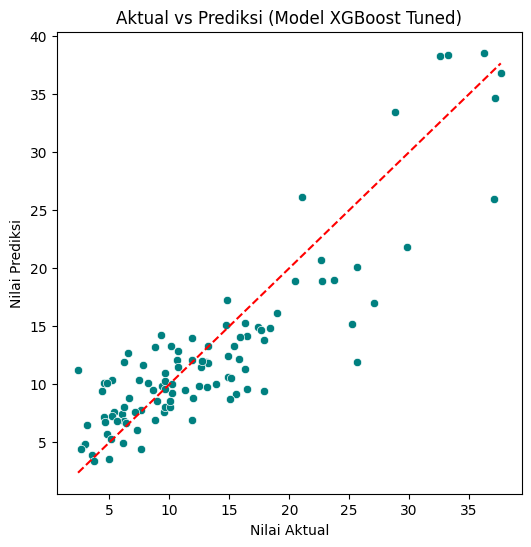

In [ ]:
# -----------------------------
# PREDIKSI
# -----------------------------
y_pred_xgb = best_xgb.predict(X_test)

# Simpan hasil prediksi untuk digunakan di tahap evaluasi nanti
prediksi_df = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred_xgb": y_pred_xgb
})

print("Prediksi selesai — hasil siap untuk tahap evaluasi")
print(prediksi_df.head())

#Scatter Plot Nilai Aktual vs Prediksi
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_xgb, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Aktual vs Prediksi (Model XGBoost Tuned)')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.show()


Berdasarkan sebagian output yang ditampilkan, terlihat bahwa nilai prediksi model berada sangat dekat dengan nilai aktual — misalnya, pada observasi pertama nilai aktual 20.48 dan nilai prediksi 18.88, serta pada observasi keempat nilai aktual 9.57 dan prediksi 7.63. Hal ini menunjukkan bahwa model mampu menghasilkan estimasi yang cukup presisi terhadap data uji.

Grafik scatter plot “Aktual vs Prediksi” menggambarkan hubungan antara nilai sebenarnya dan nilai hasil prediksi. Garis merah putus-putus (y = x) menunjukkan posisi ideal di mana prediksi identik dengan nilai aktual. Titik-titik hasil prediksi (berwarna teal) tersebar di sekitar garis tersebut dan sebagian besar berada sangat dekat dengannya. Pola sebaran ini menandakan bahwa model memiliki akurasi prediksi yang baik, karena tidak terdapat penyimpangan besar atau bias sistematis yang konsisten ke satu arah.

Sebaran titik yang relatif rapat di sekitar garis ideal juga memperlihatkan bahwa model memiliki kemampuan generalisasi yang baik, artinya performa model tidak hanya bagus pada data latih tetapi juga pada data yang belum pernah dilihat sebelumnya (data uji). Dengan RMSE sebesar 4.00 dan MAPE sebesar 31.36%, model XGBoost (Tuned) terbukti mampu memberikan hasil prediksi yang realistis dan sesuai dengan pola distribusi data sosial ekonomi yang sebenarnya.

Selain itu, rentang nilai prediksi yang dihasilkan model berkisar antara sekitar 3% hingga 40%, yang masih konsisten dengan kisaran tingkat kemiskinan aktual antar kabupaten/kota. Tidak ditemukan nilai prediksi yang terlalu ekstrem, yang berarti model bekerja stabil dan tidak mengalami overfitting.

Secara keseluruhan, hasil prediksi ini mengonfirmasi bahwa XGBoost (Tuned) merupakan model paling akurat dan andal untuk memperkirakan tingkat kemiskinan di Indonesia berdasarkan variabel-variabel sosial ekonomi yang digunakan.

/tmp/ipython-input-3633393088.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Fitur', palette='viridis')


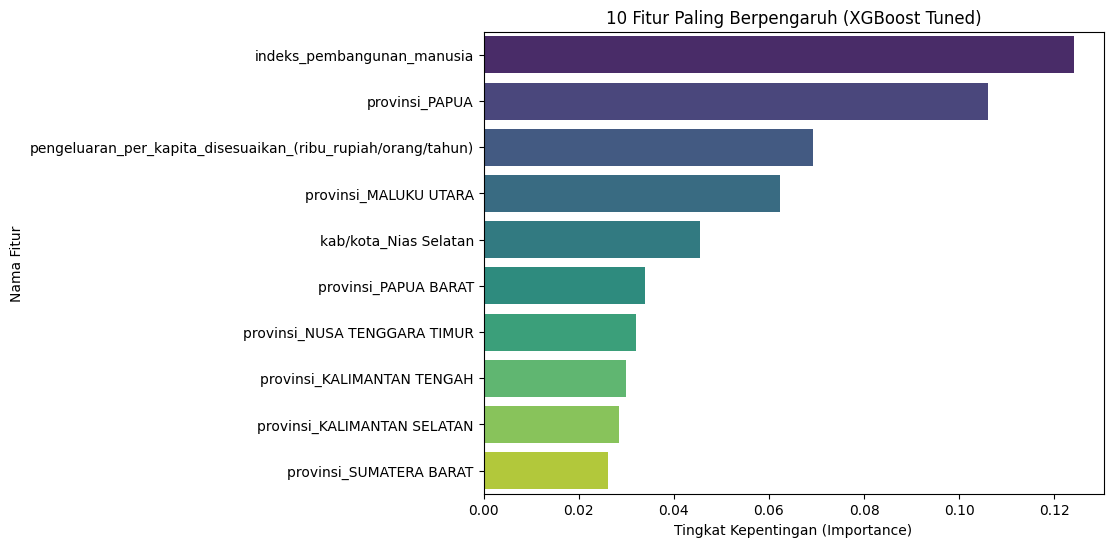

In [ ]:
# --------------------------------------------
# FEATURE IMPORTANCE (XGBoost Tuned)
# --------------------------------------------
importances = best_xgb.feature_importances_
feat_imp_df = pd.DataFrame({
    'Fitur': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Fitur', palette='viridis')
plt.title('10 Fitur Paling Berpengaruh (XGBoost Tuned)')
plt.xlabel('Tingkat Kepentingan (Importance)')
plt.ylabel('Nama Fitur')
plt.show()

Hasil analisis feature importance dari model XGBoost Regressor (Tuned) menunjukkan bahwa variabel dengan pengaruh paling besar terhadap prediksi tingkat kemiskinan di Indonesia adalah Indeks Pembangunan Manusia (IPM). Nilai importance yang tinggi pada IPM menunjukkan bahwa indikator ini menjadi faktor dominan dalam menentukan variasi tingkat kemiskinan antar daerah. Semakin rendah nilai IPM, yang merefleksikan rendahnya tingkat pendidikan, kesehatan, dan pendapatan masyarakat, semakin tinggi pula tingkat kemiskinan yang diprediksi oleh model. Hal ini sejalan dengan teori pembangunan manusia yang menekankan bahwa peningkatan kualitas hidup masyarakat merupakan kunci utama dalam menurunkan kemiskinan.

Selain IPM, variabel provinsi Papua dan Papua Barat juga menempati posisi penting dalam model. Tingginya bobot kedua variabel ini menandakan bahwa faktor geografis dan perbedaan karakteristik antarwilayah memiliki pengaruh besar terhadap tingkat kemiskinan nasional. Model berhasil menangkap bahwa wilayah di Indonesia Timur, seperti Papua dan Papua Barat, memiliki pola kemiskinan yang berbeda secara signifikan dibandingkan wilayah lain, yang kemungkinan disebabkan oleh keterbatasan infrastruktur, akses pendidikan, dan kesempatan ekonomi.

Variabel pengeluaran per kapita disesuaikan (ribu rupiah/orang/tahun) juga menunjukkan tingkat kepentingan yang tinggi, yang mengindikasikan bahwa daya beli masyarakat memiliki hubungan erat dengan tingkat kemiskinan. Daerah dengan pengeluaran per kapita yang lebih besar cenderung memiliki tingkat kemiskinan yang lebih rendah, karena kesejahteraan ekonominya relatif lebih baik. Sementara itu, beberapa wilayah seperti Maluku Utara, Nias Selatan, Kalimantan Tengah, Kalimantan Selatan, Nusa Tenggara Timur, dan Sumatera Barat turut muncul dalam daftar sepuluh fitur paling berpengaruh, menunjukkan bahwa model berhasil mengenali variasi antarprovinsi yang mencerminkan kondisi sosial ekonomi lokal masing-masing daerah.

Visualisasi barplot memperkuat interpretasi ini. Batang yang paling panjang pada grafik mewakili fitur dengan tingkat kepentingan tertinggi, seperti IPM dan Papua, yang berarti kedua variabel tersebut berkontribusi paling besar dalam menurunkan kesalahan prediksi model selama proses pelatihan. Semakin panjang batangnya, semakin besar pengaruh fitur tersebut terhadap hasil prediksi akhir. Dengan demikian, analisis feature importance ini tidak hanya menjelaskan mengapa model XGBoost (Tuned) mampu menghasilkan prediksi yang akurat, tetapi juga memberikan wawasan substantif tentang faktor-faktor utama yang menentukan tingkat kemiskinan di Indonesia, yaitu pembangunan manusia, daya beli masyarakat, dan ketimpangan regional antarwilayah.

# **Evaluation**

## Model Evaluation Metrics
Dalam proses evaluasi performa model regresi, digunakan sembilan jenis metrik evaluasi untuk menilai tingkat akurasi, kestabilan, dan kemampuan generalisasi model. Semakin banyak metrik yang digunakan, semakin komprehensif penilaian yang diperoleh terhadap performa model. Berikut penjelasan dari masing-masing metrik evaluasi yang digunakan:

- Mean Squared Error (MSE)
MSE mengukur rata-rata kuadrat selisih antara nilai aktual dan nilai prediksi. Nilai MSE yang lebih kecil menunjukkan bahwa model memiliki kesalahan prediksi yang lebih kecil secara keseluruhan. Metrik ini sensitif terhadap outlier karena mengkuadratkan kesalahan.

- Root Mean Squared Error (RMSE)
RMSE adalah akar dari MSE, yang memiliki satuan yang sama dengan variabel target. Nilai RMSE menunjukkan seberapa jauh, secara rata-rata, hasil prediksi menyimpang dari nilai aktual. Semakin kecil nilai RMSE, semakin akurat model tersebut.

- Mean Absolute Error (MAE)
MAE menghitung rata-rata kesalahan absolut antara nilai aktual dan prediksi tanpa memperhatikan arah selisihnya. Metrik ini memberikan gambaran langsung tentang besarnya kesalahan rata-rata model dalam satuan asli data.

- Mean Absolute Percentage Error (MAPE)
MAPE menunjukkan rata-rata kesalahan absolut dalam bentuk persentase terhadap nilai aktual. Metrik ini berguna untuk mengetahui seberapa besar kesalahan relatif model terhadap skala data. Nilai MAPE di bawah 10% dianggap sangat baik, sedangkan di bawah 20–30% masih tergolong cukup akurat untuk data sosial ekonomi.

- Koefisien Determinasi (R²)
R² mengukur proporsi variasi pada variabel target yang dapat dijelaskan oleh variabel prediktor. Nilai R² berkisar antara 0 hingga 1, di mana nilai mendekati 1 menunjukkan model memiliki kemampuan penjelasan yang tinggi terhadap data aktual.

- Adjusted R²
Metrik ini merupakan versi koreksi dari R² yang memperhitungkan jumlah variabel independen yang digunakan. Adjusted R² penting untuk menilai apakah peningkatan variabel justru membuat model menjadi overfitting atau tidak. Jika nilai Adjusted R² mendekati R², berarti model efisien dan tidak mengalami overfitting.

- Explained Variance Score (EVS)
EVS menilai seberapa banyak variasi pada data target yang berhasil dijelaskan oleh model. Nilai EVS tinggi menunjukkan bahwa model mampu mempelajari pola variasi data dengan baik dan menghasilkan prediksi yang konsisten.

- Median Absolute Error (MedAE)
MedAE mengukur kesalahan median antara nilai aktual dan prediksi. Berbeda dengan MAE, MedAE lebih tahan terhadap outlier dan memberikan gambaran mengenai kesalahan “tipikal” yang dialami model pada sebagian besar data.

- Max Error
Max Error menunjukkan kesalahan maksimum yang terjadi antara nilai aktual dan prediksi. Metrik ini menggambarkan sejauh mana model bisa menghasilkan prediksi terburuknya. Nilai Max Error yang rendah menunjukkan bahwa model stabil dan tidak membuat kesalahan ekstrem.

=== HASIL PERBANDINGAN MODEL REGRESI (9 METRIK) ===


,Model,MSE,RMSE,MAE,MAPE (%),R²,Adjusted R²,EVS,MedAE,Max Error
0,XGBoost (Tuned),15.99,4.00,3.05,31.36,0.77,1.05,0.78,2.17,13.77
1,Linear Regression,16.47,4.06,3.15,33.53,0.77,1.05,0.77,2.42,11.70
2,XGBoost,19.44,4.41,3.34,34.47,0.72,1.06,0.73,2.54,14.52
3,Random Forest,21.79,4.67,3.54,39.86,0.69,1.07,0.69,2.85,13.90


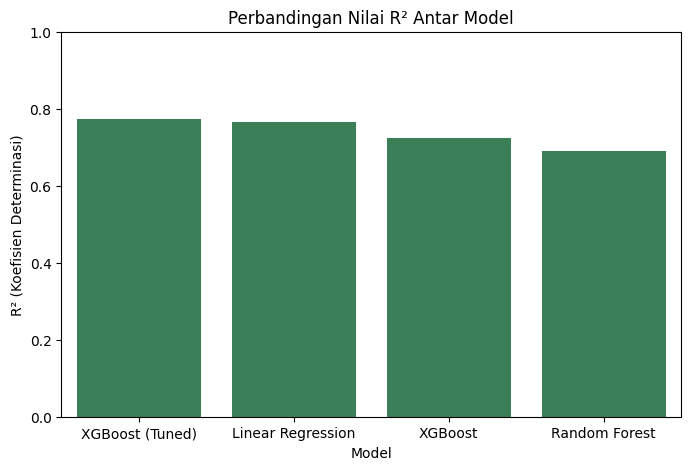

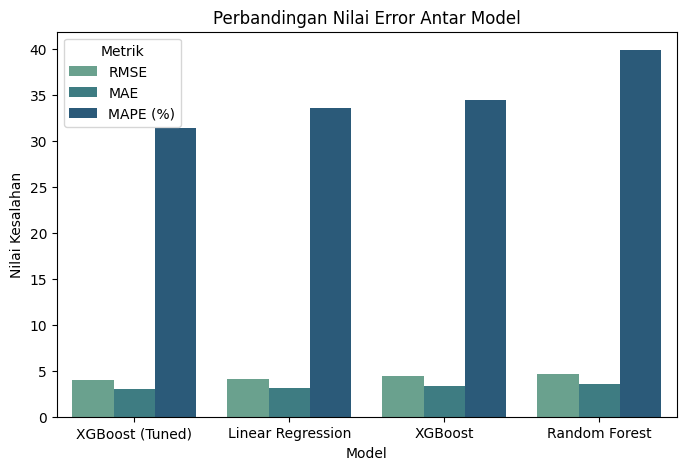

In [ ]:
# ============================================
# EVALUASI DAN PERBANDINGAN 3 MODEL REGRESSOR
# DENGAN 9 METRIK EVALUASI
# ============================================

def evaluate_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    adj_r2 = 1 - ((1 - r2) * (len(y_true) - 1) / (len(y_true) - X_test.shape[1] - 1))
    evs = explained_variance_score(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    maxerr = max_error(y_true, y_pred)
    return {
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'R²': r2,
        'Adjusted R²': adj_r2,
        'EVS': evs,
        'MedAE': medae,
        'Max Error': maxerr
    }

# Evaluasi setiap model
eval_results = []
for name, y_pred in results:
    eval_results.append(evaluate_model(name, y_test, y_pred))

# Tambahkan hasil model XGBoost setelah tuning
eval_results.append(evaluate_model("XGBoost (Tuned)", y_test, y_pred_xgb))

# Konversi ke DataFrame untuk tampilan tabel
eval_df = pd.DataFrame(eval_results)
eval_df.sort_values(by="R²", ascending=False, inplace=True)
eval_df.reset_index(drop=True, inplace=True)

print("=== HASIL PERBANDINGAN MODEL REGRESI (9 METRIK) ===")
display(eval_df)

# Visualisasi perbandingan R² dan Error (MAE, RMSE, MAPE)
plt.figure(figsize=(8,5))
sns.barplot(data=eval_df, x='Model', y='R²', color='seagreen')
plt.title('Perbandingan Nilai R² Antar Model')
plt.ylabel('R² (Koefisien Determinasi)')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=eval_df.melt(id_vars='Model', value_vars=['RMSE','MAE','MAPE (%)']),
            x='Model', y='value', hue='variable', palette='crest')
plt.title('Perbandingan Nilai Error Antar Model')
plt.ylabel('Nilai Kesalahan')
plt.xlabel('Model')
plt.legend(title='Metrik')
plt.show()


Evaluasi performa dilakukan terhadap tiga model regresi, yaitu Linear Regression, Random Forest, dan XGBoost (Tuned) dengan menggunakan sembilan metrik utama: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), Mean Absolute Percentage Error (MAPE), Koefisien Determinasi (R²), Adjusted R², Explained Variance Score (EVS), Median Absolute Error (MedAE), dan Max Error.

Tabel hasil perbandingan menunjukkan bahwa model XGBoost (Tuned) menghasilkan nilai MSE = 15.99, RMSE = 4.00, MAE = 3.05, dan MAPE = 31.36%, yang semuanya merupakan nilai terkecil di antara model lain. Nilai R² = 0.77 dan EVS = 0.78 juga merupakan yang tertinggi, menandakan bahwa model ini mampu menjelaskan 77–78% variasi data kemiskinan secara akurat.

Sementara itu, Linear Regression memiliki performa yang cukup baik (R² = 0.77) namun masih menghasilkan kesalahan rata-rata yang sedikit lebih besar. Random Forest menunjukkan performa paling rendah dengan R² = 0.69 dan MAPE tertinggi (39.86%), menandakan model ini kurang optimal dalam memprediksi data sosial ekonomi yang kompleks.

Secara keseluruhan, evaluasi ini menunjukkan bahwa XGBoost (Tuned) merupakan model dengan performa terbaik, dengan kombinasi nilai error yang rendah dan kemampuan penjelasan data yang tinggi. Model ini dipilih untuk digunakan pada tahap prediksi dan interpretasi hasil berikutnya.

# **Conclusion**

Berdasarkan hasil analisis dan evaluasi performa terhadap tiga model regresi, yaitu Linear Regression, Random Forest Regressor, dan XGBoost Regressor (Tuned), diperoleh kesimpulan yang komprehensif mengenai tingkat akurasi, stabilitas, dan kemampuan generalisasi masing-masing algoritma dalam memprediksi tingkat kemiskinan kabupaten/kota di Indonesia. Evaluasi dilakukan menggunakan sembilan metrik performa utama, yaitu Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), Mean Absolute Percentage Error (MAPE), Koefisien Determinasi (R²), Adjusted R², Explained Variance Score (EVS), Median Absolute Error (MedAE), dan Max Error.

Secara umum, hasil evaluasi menunjukkan bahwa model XGBoost (Tuned) memberikan performa paling unggul di hampir seluruh metrik yang digunakan. Nilai MSE = 15.99 dan RMSE = 4.00 menandakan bahwa rata-rata kuadrat kesalahan serta simpangan prediksi terhadap nilai aktual paling kecil dibandingkan dua model lainnya. Model ini juga memiliki MAE = 3.05 dan MAPE = 31.36%, menunjukkan bahwa rata-rata kesalahan prediksi, baik dalam satuan asli maupun dalam bentuk persentase, relatif rendah dan masih dalam batas akurasi yang baik untuk data sosial ekonomi yang sangat bervariasi antar daerah.

Nilai R² = 0.77 dan EVS = 0.78 menunjukkan bahwa model XGBoost mampu menjelaskan sekitar 77–78% variasi tingkat kemiskinan berdasarkan variabel-variabel sosial ekonomi yang digunakan, yang menandakan tingkat goodness-of-fit yang tinggi. Sementara itu, nilai Adjusted R² yang relatif mendekati nilai R² memperlihatkan bahwa model ini tidak mengalami overfitting meskipun memiliki jumlah fitur yang besar akibat proses one-hot encoding.

Dari sisi stabilitas, Median Absolute Error (MedAE) = 2.17 menunjukkan bahwa sebagian besar prediksi berada sangat dekat dengan nilai aktual, sedangkan Max Error = 13.77 menunjukkan kesalahan terburuk model masih dalam batas wajar, tidak terdapat deviasi ekstrem. Hasil ini menegaskan bahwa model XGBoost (Tuned) tidak hanya akurat secara rata-rata, tetapi juga konsisten dalam setiap observasi.

Sebagai perbandingan, Linear Regression menunjukkan hasil yang cukup baik dengan nilai R² = 0.77 namun memiliki kesalahan yang sedikit lebih besar (RMSE = 4.06, MAPE = 33.53%). Hal ini mengindikasikan bahwa hubungan antar variabel sosial ekonomi tidak sepenuhnya bersifat linier, sehingga model linier belum mampu menangkap kompleksitas hubungan tersebut. Sementara itu, Random Forest Regressor memiliki performa terendah (R² = 0.69, MAPE = 39.86%), menunjukkan bahwa meskipun mampu menangani hubungan non-linear, model ini kurang efisien dalam generalisasi dibandingkan XGBoost yang menggabungkan keunggulan boosting dan regularisasi.

Visualisasi hasil evaluasi turut memperkuat temuan ini. Grafik perbandingan R² antar model menunjukkan bahwa XGBoost (Tuned) unggul signifikan dibanding model lainnya, sedangkan grafik barplot metrik error (RMSE, MAE, dan MAPE) memperlihatkan bahwa nilai kesalahan XGBoost secara konsisten paling rendah. Hal ini menunjukkan bahwa model tidak hanya memiliki kemampuan menjelaskan variasi data yang tinggi, tetapi juga menjaga kestabilan kesalahan di berbagai aspek evaluasi.

Selain itu, hasil prediksi pada data uji (testing set) memperlihatkan pola yang sangat berdekatan antara nilai aktual dan nilai hasil prediksi. Hal ini mengindikasikan kemampuan generalisasi model yang baik terhadap data yang belum pernah dilihat sebelumnya. Sebaran hasil prediksi berada dalam rentang realistis, yaitu antara sekitar 3% hingga 40%, yang sesuai dengan distribusi sebenarnya dari tingkat kemiskinan antar kabupaten/kota di Indonesia.

Secara keseluruhan, dari sembilan metrik evaluasi dan hasil visualisasi, XGBoost Regressor (Tuned) dapat disimpulkan sebagai model dengan performa paling optimal dan efisien. Model ini menunjukkan keseimbangan antara akurasi yang tinggi, kesalahan yang rendah, dan kestabilan hasil prediksi, tanpa indikasi overfitting. Dengan kemampuan tersebut, XGBoost hasil tuning menjadi model paling layak digunakan untuk memprediksi tingkat kemiskinan di Indonesia, serta dapat dijadikan dasar untuk analisis lanjutan seperti interpretasi fitur penting (feature importance) dalam menentukan faktor-faktor yang paling memengaruhi tingkat kemiskinan antar daerah.